In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)


In [2]:
df = pd.read_csv("playtennis1.csv")
df


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [3]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

df


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [7]:
X = df.drop('Play Tennis', axis=1)

y = df['Play Tennis']


In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [9]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [11]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-Score :", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


In [12]:
evaluate(y_test, y_pred_dt, "Decision Tree (ID3)")
evaluate(y_test, y_pred_rf, "Random Forest")



Decision Tree (ID3)
Accuracy : 0.6
Precision: 0.6666666666666666
Recall   : 0.6666666666666666
F1-Score : 0.6666666666666666
Confusion Matrix:
 [[1 1]
 [1 2]]

Random Forest
Accuracy : 0.6
Precision: 0.6666666666666666
Recall   : 0.6666666666666666
F1-Score : 0.6666666666666666
Confusion Matrix:
 [[1 1]
 [1 2]]


In [13]:
dt_prob = dt.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Decision Tree AUROC:", roc_auc_score(y_test, dt_prob))
print("Random Forest AUROC:", roc_auc_score(y_test, rf_prob))


Decision Tree AUROC: 0.5833333333333333
Random Forest AUROC: 0.6666666666666666


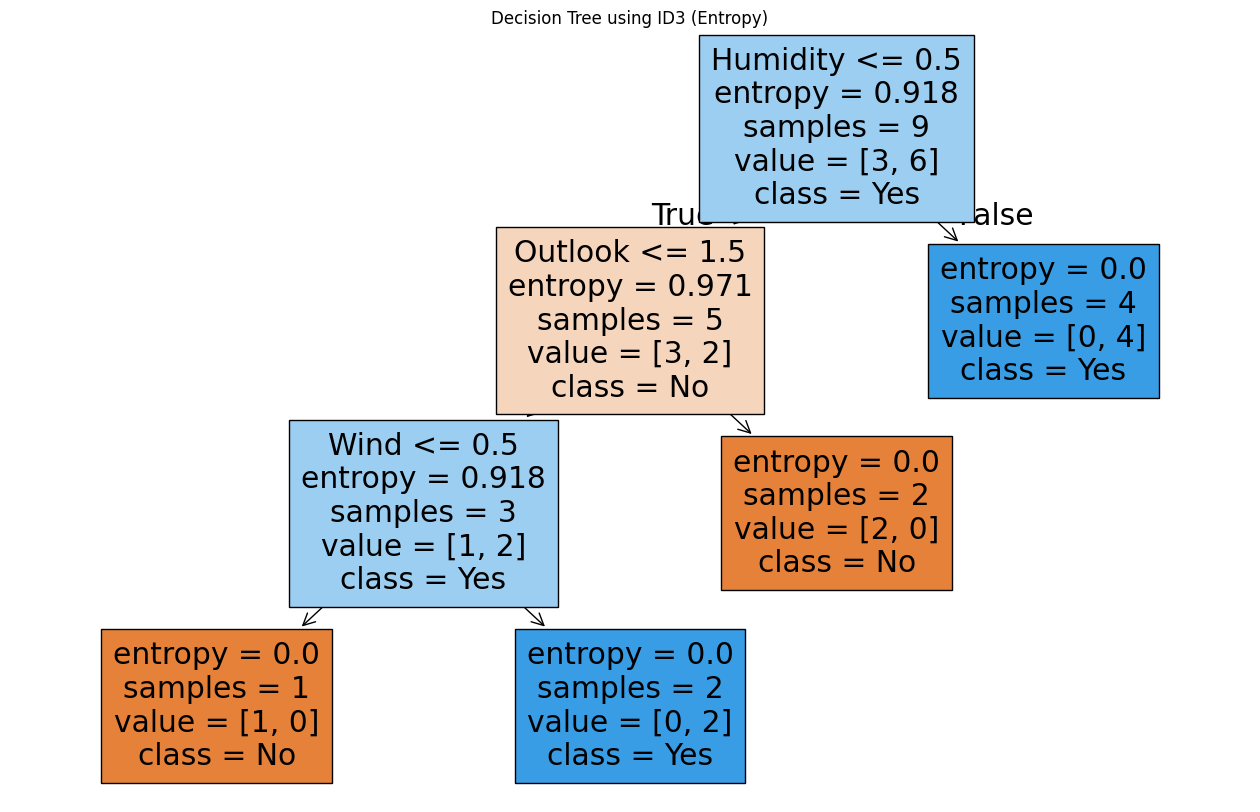

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)
plt.title("Decision Tree using ID3 (Entropy)")
plt.show()


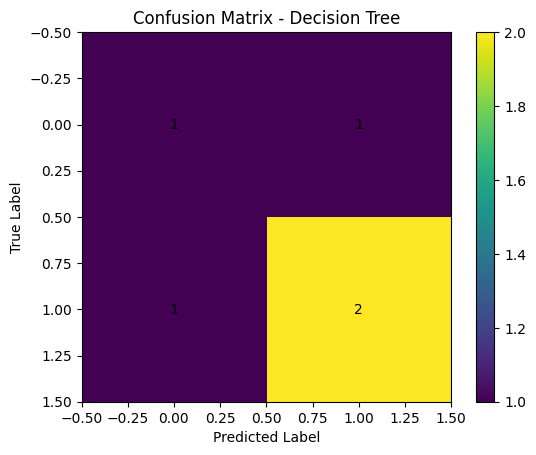

In [15]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure()
plt.imshow(cm_dt)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        plt.text(j, i, cm_dt[i, j], ha="center", va="center")

plt.show()


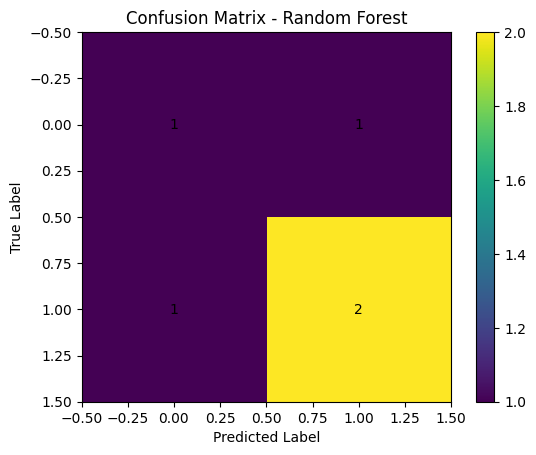

In [16]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
plt.imshow(cm_rf)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.show()


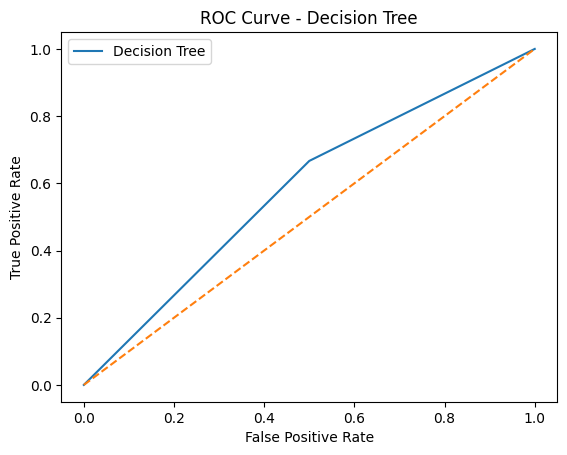

In [17]:
from sklearn.metrics import roc_curve

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

plt.figure()
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()


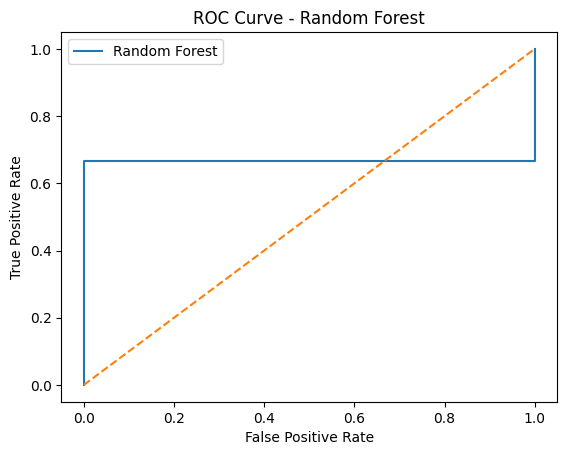

In [18]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


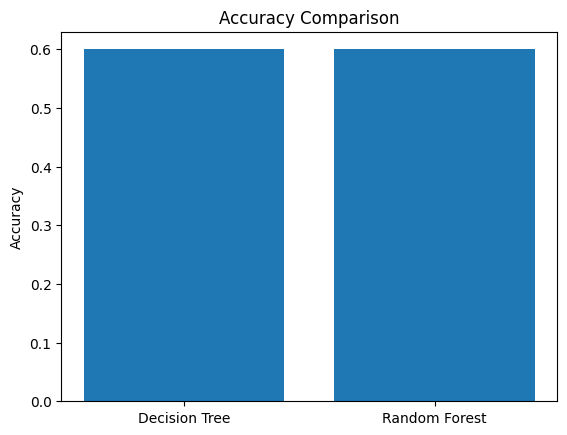

In [19]:
models = ['Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()
